In [1]:
import pandas as pd

df = pd.read_csv("../data/CRMLSSold202605.csv")

print(df.shape)
df.head()

(23260, 78)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,OutOfAreaBoard,CitrusValley,NaN,True,NaN,NaN,False,635000.0,1171672853,mike@bhfmortgage.com,...,NaN,57149.0,1.0,False,1.0,Long Beach Unified,90802,785.0,57149.0,NaN
1,SouthBay,SouthBay,Wood,True,NaN,NaN,False,8712500.0,1171668711,EK@ITZSOLD.COM,...,NaN,2703.0,2.0,False,4.0,Manhattan Unified,90266,0.0,2703.0,NaN
2,PacificWest,SouthBay,NaN,True,NaN,NaN,True,4194.0,1171656528,James.daniel@exprealty.com,...,NaN,0.0,3.0,False,2.0,Los Angeles Unified,90732,0.0,0.0,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,1100000.0,1171617616,cmorton@crownrealtyteam.com,...,NaN,47541.0,NaN,False,0.0,NaN,91902,NaN,47541.0,NaN
4,SouthBay,SouthBay,"Laminate,Vinyl",False,NaN,NaN,False,1400000.0,1171562218,dean@caskeyrealestategroup.com,...,NaN,5756.0,3.0,False,1.0,Redondo Unified,90277,0.0,5756.0,NaN


In [2]:
print(df.columns.tolist())

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [3]:
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]

In [4]:
print(df.shape)

(12024, 78)


In [5]:
df["ClosePrice"].describe()

count    1.202400e+04
mean     1.309789e+06
std      1.678130e+06
min      1.190000e+04
25%      6.390000e+05
50%      9.300000e+05
75%      1.500000e+06
max      9.797250e+07
Name: ClosePrice, dtype: float64

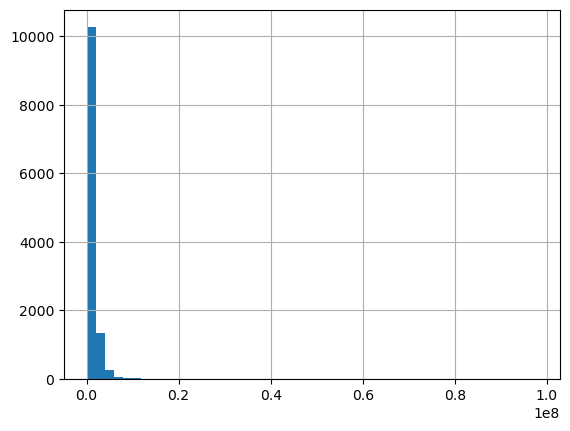

In [6]:
import matplotlib.pyplot as plt

df["ClosePrice"].hist(bins=50)
plt.show()

In [7]:
features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "ClosePrice"
]

df[features].describe()

,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,ClosePrice
count,12017.000000,12024.000000,12024.000000,1.182000e+04,1.202400e+04
mean,2074.003661,3.515136,2.665003,9.225210e+04,1.309789e+06
std,1038.229655,0.955260,1.137134,5.273723e+06,1.678130e+06
min,0.000000,0.000000,0.000000,0.000000e+00,1.190000e+04
25%,1401.000000,3.000000,2.000000,5.663000e+03,6.390000e+05
50%,1853.000000,3.000000,2.000000,7.250000e+03,9.300000e+05
75%,2470.000000,4.000000,3.000000,1.045400e+04,1.500000e+06
max,23314.000000,11.000000,22.000000,4.706658e+08,9.797250e+07


In [8]:
missing = df.isnull().sum()

missing.sort_values(ascending=False).head(20)

MiddleOrJuniorSchoolDistrict    12024
FireplacesTotal                 12024
AboveGradeFinishedArea          12024
TaxAnnualAmount                 12024
TaxYear                         12024
ElementarySchoolDistrict        12024
CoveredSpaces                   12024
BusinessType                    12024
WaterfrontYN                    12018
BelowGradeFinishedArea          11926
BasementYN                      11717
BuilderName                     11492
LotSizeDimensions               11316
BuildingAreaTotal               11237
CoBuyerAgentFirstName           10851
MiddleOrJuniorSchool            10390
ElementarySchool                10377
HighSchool                       9872
CoListAgentFirstName             9243
CoListAgentLastName              9235
dtype: int64

In [9]:
numeric = df.select_dtypes(include=["number"])

corr = numeric.corr(numeric_only=True)

corr["ClosePrice"].sort_values(ascending=False).head(20)

ClosePrice                1.000000
ListPrice                 0.806907
BuildingAreaTotal         0.744692
LivingArea                0.514557
BathroomsTotalInteger     0.461947
BedroomsTotal             0.277003
AssociationFee            0.234602
BelowGradeFinishedArea    0.204888
Stories                   0.170430
OriginalListPrice         0.163812
LotSizeArea               0.058774
GarageSpaces              0.032944
ListingKeyNumeric         0.021261
ListingKey                0.021261
ParkingTotal              0.021069
YearBuilt                 0.005341
DaysOnMarket              0.002704
LotSizeSquareFeet        -0.001003
LotSizeAcres             -0.001003
Latitude                 -0.011336
Name: ClosePrice, dtype: float64

# Week 2 Summary and Key Findings

## Dataset Overview

The June 2026 CRMLS sold-property dataset initially contained **23,260 observations and 78 features**. To align with the project requirements, the dataset was filtered to include only properties where:

- PropertyType = Residential
- PropertySubType = SingleFamilyResidence

After filtering, the dataset contained **12,024 residential single-family home sales**, which will serve as the primary dataset for model development.

## Close Price Analysis

The target variable, **ClosePrice**, exhibits a right-skewed distribution with several high-value outliers. Most residential properties are concentrated in the lower and middle price ranges, while a small number of luxury properties extend the distribution to very high values.

### Key Observations

- Mean ClosePrice ≈ \$1.31 million
- Median ClosePrice ≈ \$930,000
- Maximum ClosePrice ≈ \$97.97 million

The difference between the mean and median suggests that a relatively small number of extremely expensive properties significantly influence the average sale price.

## Feature Exploration

Several property characteristics were examined for their potential relationship with ClosePrice, including:

- LivingArea
- BedroomsTotal
- BathroomsTotalInteger
- LotSizeSquareFeet
- BuildingAreaTotal

Descriptive statistics indicate substantial variation across properties, suggesting that these features may provide meaningful predictive power for machine learning models.

## Missing Value Assessment

The dataset contains missing values across multiple features. Several columns related to school districts and supplemental property information contain very high percentages of missing values and may require removal or special handling during preprocessing.

Future preprocessing steps will include:

- Identifying columns with excessive missingness
- Determining whether to impute, remove, or create missing-value indicators
- Evaluating the impact of missing data on model performance

## Correlation Findings

Correlation analysis identified several variables with strong positive relationships to ClosePrice:

| Feature | Correlation with ClosePrice |
|----------|----------:|
| ListPrice | 0.807 |
| BuildingAreaTotal | 0.745 |
| LivingArea | 0.515 |
| BathroomsTotalInteger | 0.462 |
| BedroomsTotal | 0.277 |

These results suggest that property size and listing price are among the strongest predictors of final sale price.

## Conclusions

The exploratory analysis indicates that residential property prices are heavily influenced by home size, building area, and bathroom count. The dataset contains sufficient variation and volume to support predictive modeling. However, missing values and extreme outliers will require additional preprocessing before model training.

The dataset is now ready for **Week 3: Data Preprocessing**, which will include combining multiple months of data, handling missing values, encoding categorical variables, and preparing training and testing datasets for machine learning models.